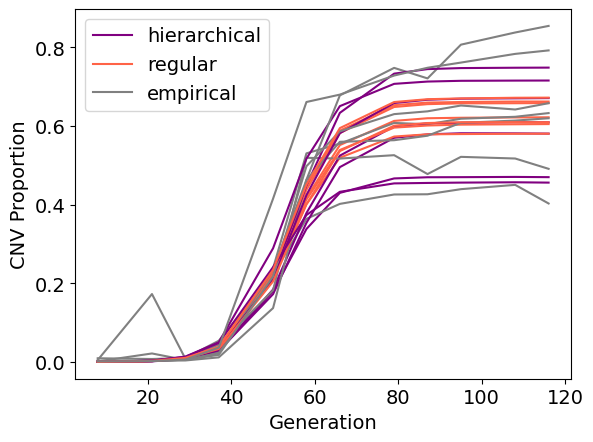

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper, wrapper_hierarchical, WF
import warnings
warnings.simplefilter('ignore', FutureWarning)

generation = np.array(pd.read_csv('empirical_data/Chuong_116_gens.txt').columns.astype('int'))

# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

th = torch.tensor([-0.74,-4.84,-4.32], dtype=torch.float32)
X = wrapper(WF, parameters=th, reps=7) # LTRΔ MAP in paper
X_emp = torch.from_numpy(np.array(pd.read_csv('empirical_data/ltr.csv', index_col=0)))
X_h = wrapper_hierarchical(WF, parameters=th, reps=7)
change_font(14)

for i in range(len(X)):
    plt.plot(generation,X_h[i], color='purple', label='hierarchical' if i==0 else '')
    plt.plot(generation,X[i], color='tomato', label='regular' if i==0 else '')
    plt.plot(generation,X_emp[i], color='grey', label='empirical' if i==0 else '')
plt.xlabel('Generation')
plt.ylabel('CNV Proportion')
plt.legend()

In [2]:
prior_min = np.log10(np.array([1e-2,1e-7,1e-8]))
prior_max = np.log10(np.array([1,1e-2,1e-2]))
prior = utils.BoxUniform(low=torch.tensor(prior_min), 
                         high=torch.tensor(prior_max))
posterior_chuong = pickle.load(open('posteriors/posterior_WF_30000_20.pkl', 'rb'))
epsilon = -150


Xs = torch.tensor(X)
op = CollectivePosterior(prior, Xs, posterior_chuong, 1, epsilon)

print(op.get_log_C())
est = op.sample(100).mean(0)
estφ

/tmp/ipykernel_1399091/2989340501.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xs = torch.tensor(X)


KeyboardInterrupt: 

In [3]:
def coverage_old(samples, conf_levels, theta):
    covs = torch.empty(len(conf_levels), len(theta))
    for j in range(len(conf_levels)):
        conf_level = conf_levels[j]   
        taken_samples = samples[:int(conf_level*len(samples))+1]
        hdi = [torch.quantile(samples, (1-conf_level)/2, 0), torch.quantile(samples,(1+conf_level)/2, 0)]
        covs[j,:] = ((theta > hdi[0])*(theta < hdi[1]))
    
    return covs

def full_covs(samples, conf_levels, thetas):
    covs_old = torch.empty(len(thetas[:,0]),len(conf_levels), len(thetas[0]))
    for i in range(len(thetas)):
        covs_old[i] = coverage_old(samples[i,:].reshape(400,3), conf_levels, theta=thetas[i])
    return covs_old

Text(0, 0.5, '')

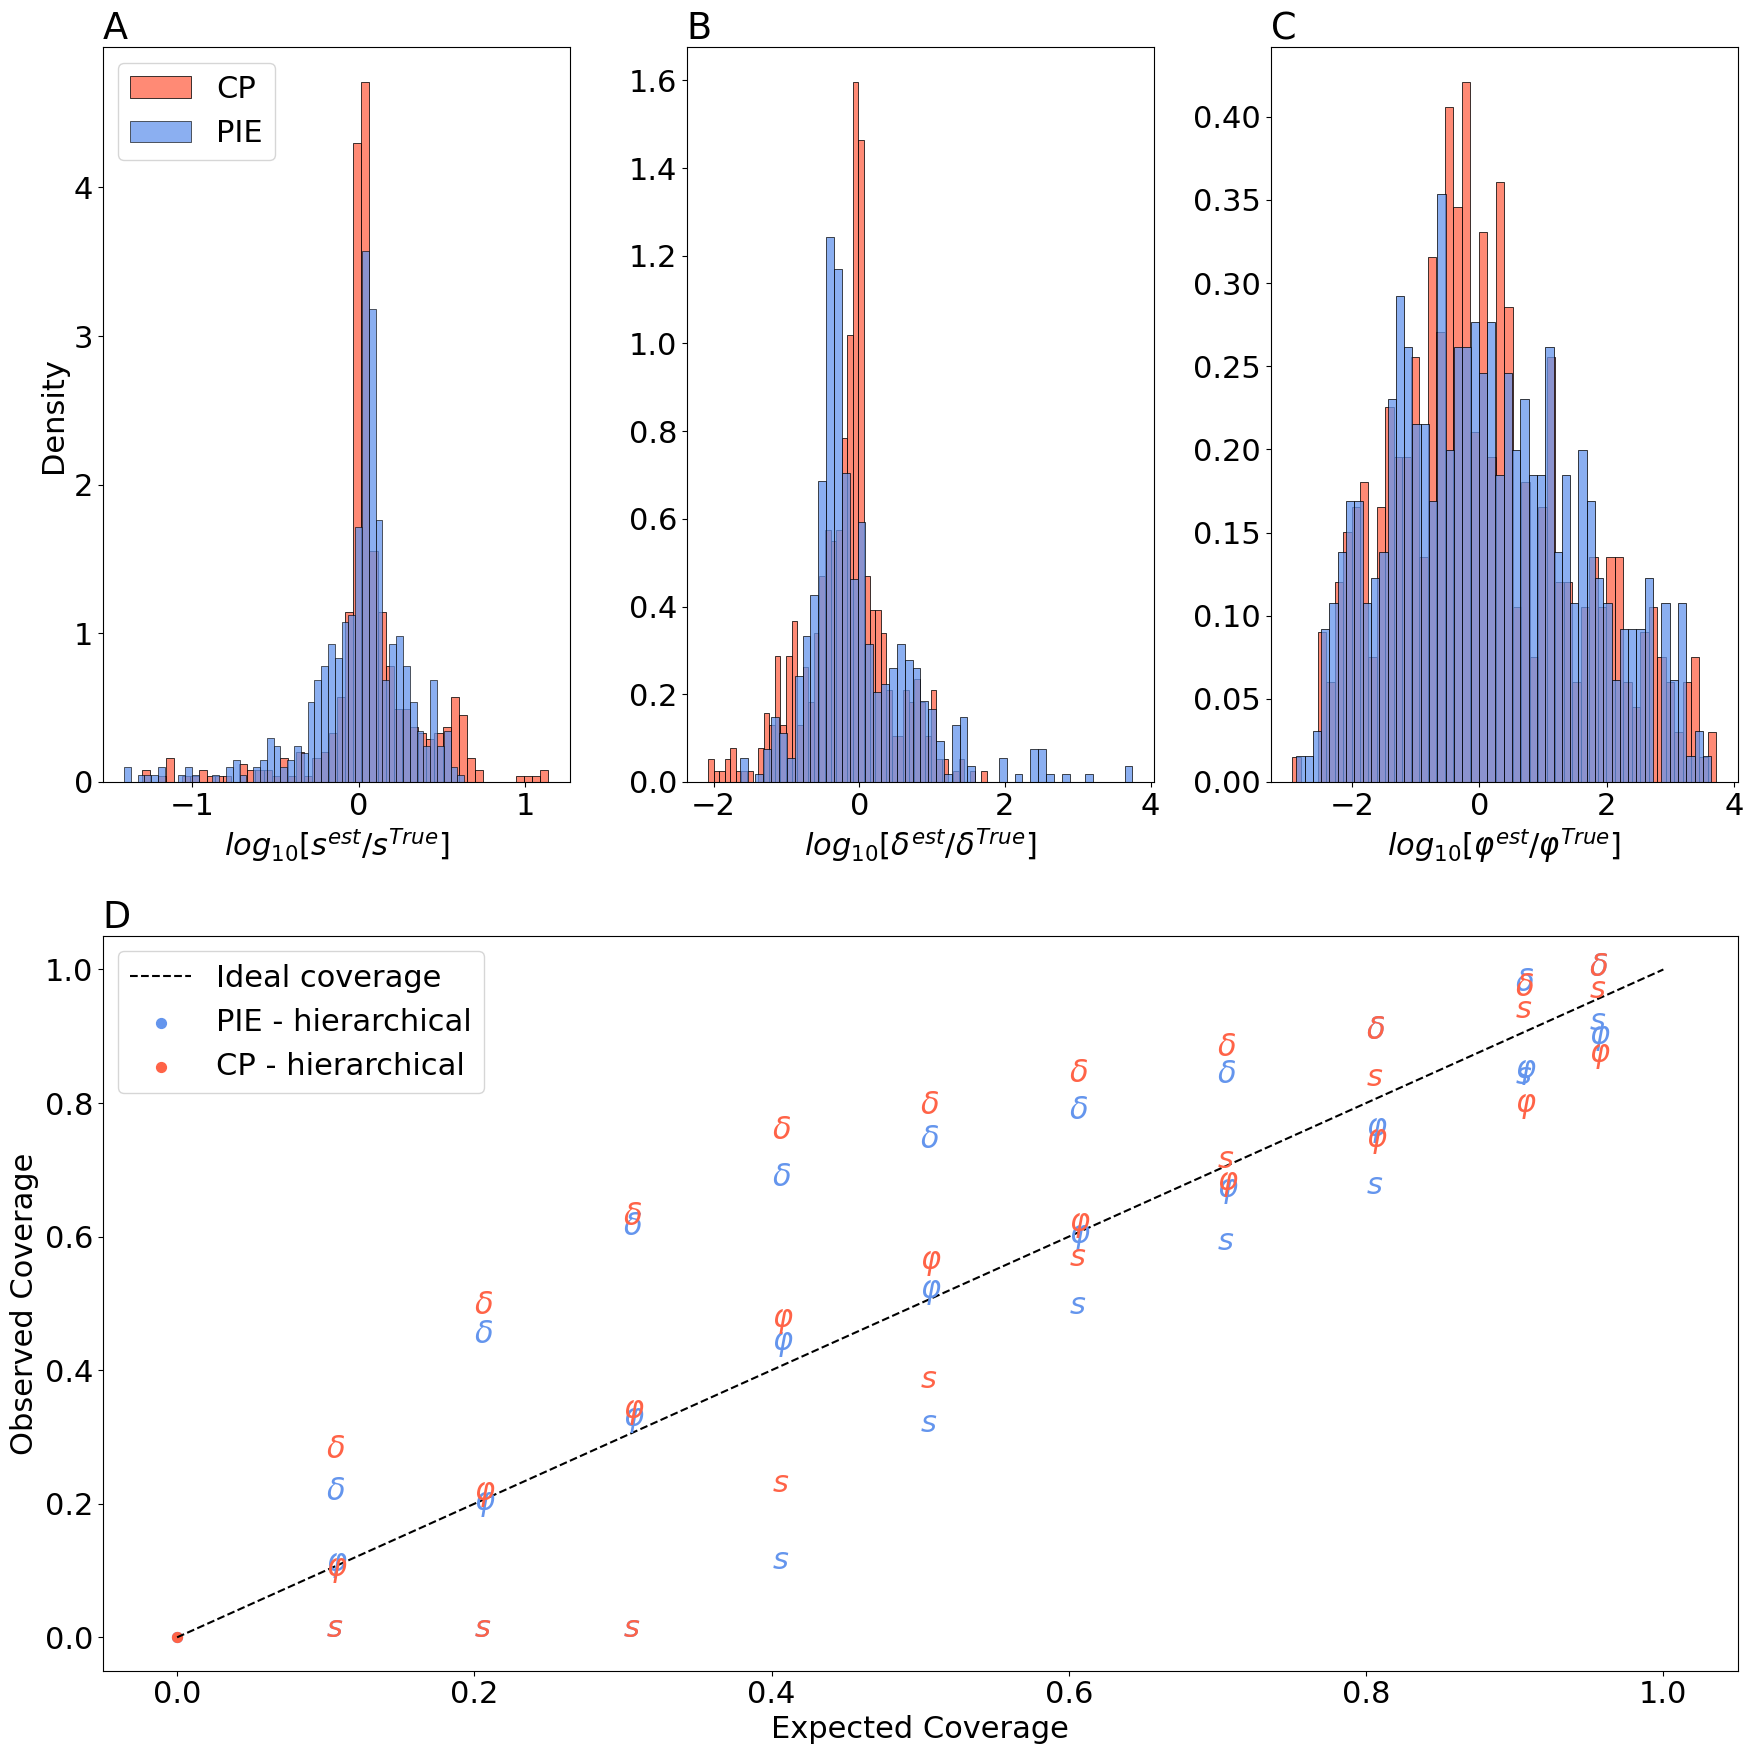

In [8]:
change_font(22)

def plot_accuracy(acc_path, ax, color, label, hatch):
    res = pd.read_csv(acc_path, index_col=0, dtype='float')
    res = torch.from_numpy(np.array(res))
    for i in range(len(ax)):
        histplot(res[:,i],ax=ax[i], stat='density', color=color, bins=50, label=label, hatch=hatch)
    return


def plot_covs_old(ax, covs, color, label):
    param_names = ['$s$', '$δ$', '$φ$']
    for i in range(len(covs.columns)):
        p = covs.columns[i]
        word = param_names[i]
        for j in range(1,len(covs[p])):
            ax.text(covs.index[j], covs[p].values[j], word, color=color)
    ax.scatter(0,0,s=50, label=label, color=color)
        
        
covs_cp = pd.read_csv('tests/covs_old_WF_r.csv', index_col=0)
covs_cp_h = pd.read_csv('tests/covs_old_WF_h_r.csv', index_col=0)
covs_cp_iid = pd.read_csv('tests/covs_old_WF_iid_r.csv', index_col=0)
covs_cp_iid_h = pd.read_csv('tests/covs_old_WF_iid_h_r.csv', index_col=0)
covs_cp_m = pd.read_csv('tests/covs_old_WF_m.csv', index_col=0)

mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
covs_iid = pd.read_csv(f'tests/covs_old_WF_iid_h_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid_h,label='PIE - hierarchical',color='cornflowerblue')
covs_ = pd.read_csv(f'tests/covs_old_WF_h_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['D'], covs=covs_cp_h,label='CP - hierarchical',color='tomato')
covs = pd.read_csv(f'tests/covs_old_WF_m.csv', index_col=0, dtype='float')
# plot_covs_old(ax=ax['D'], covs=covs,label='CP - mixed sampling',color='maroon')
ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['D'].legend()



n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_h_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='CP')

# cp_acc_m = 'tests/accus_WF_m.csv'
# plot_accuracy(cp_acc_m, axx, color='maroon', hatch='///', label='')

iid_acc = 'tests/accus_WF_iid_h_r.csv'
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='PIE')

ax['A'].legend(loc='upper left')
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



Text(0, 0.5, '')

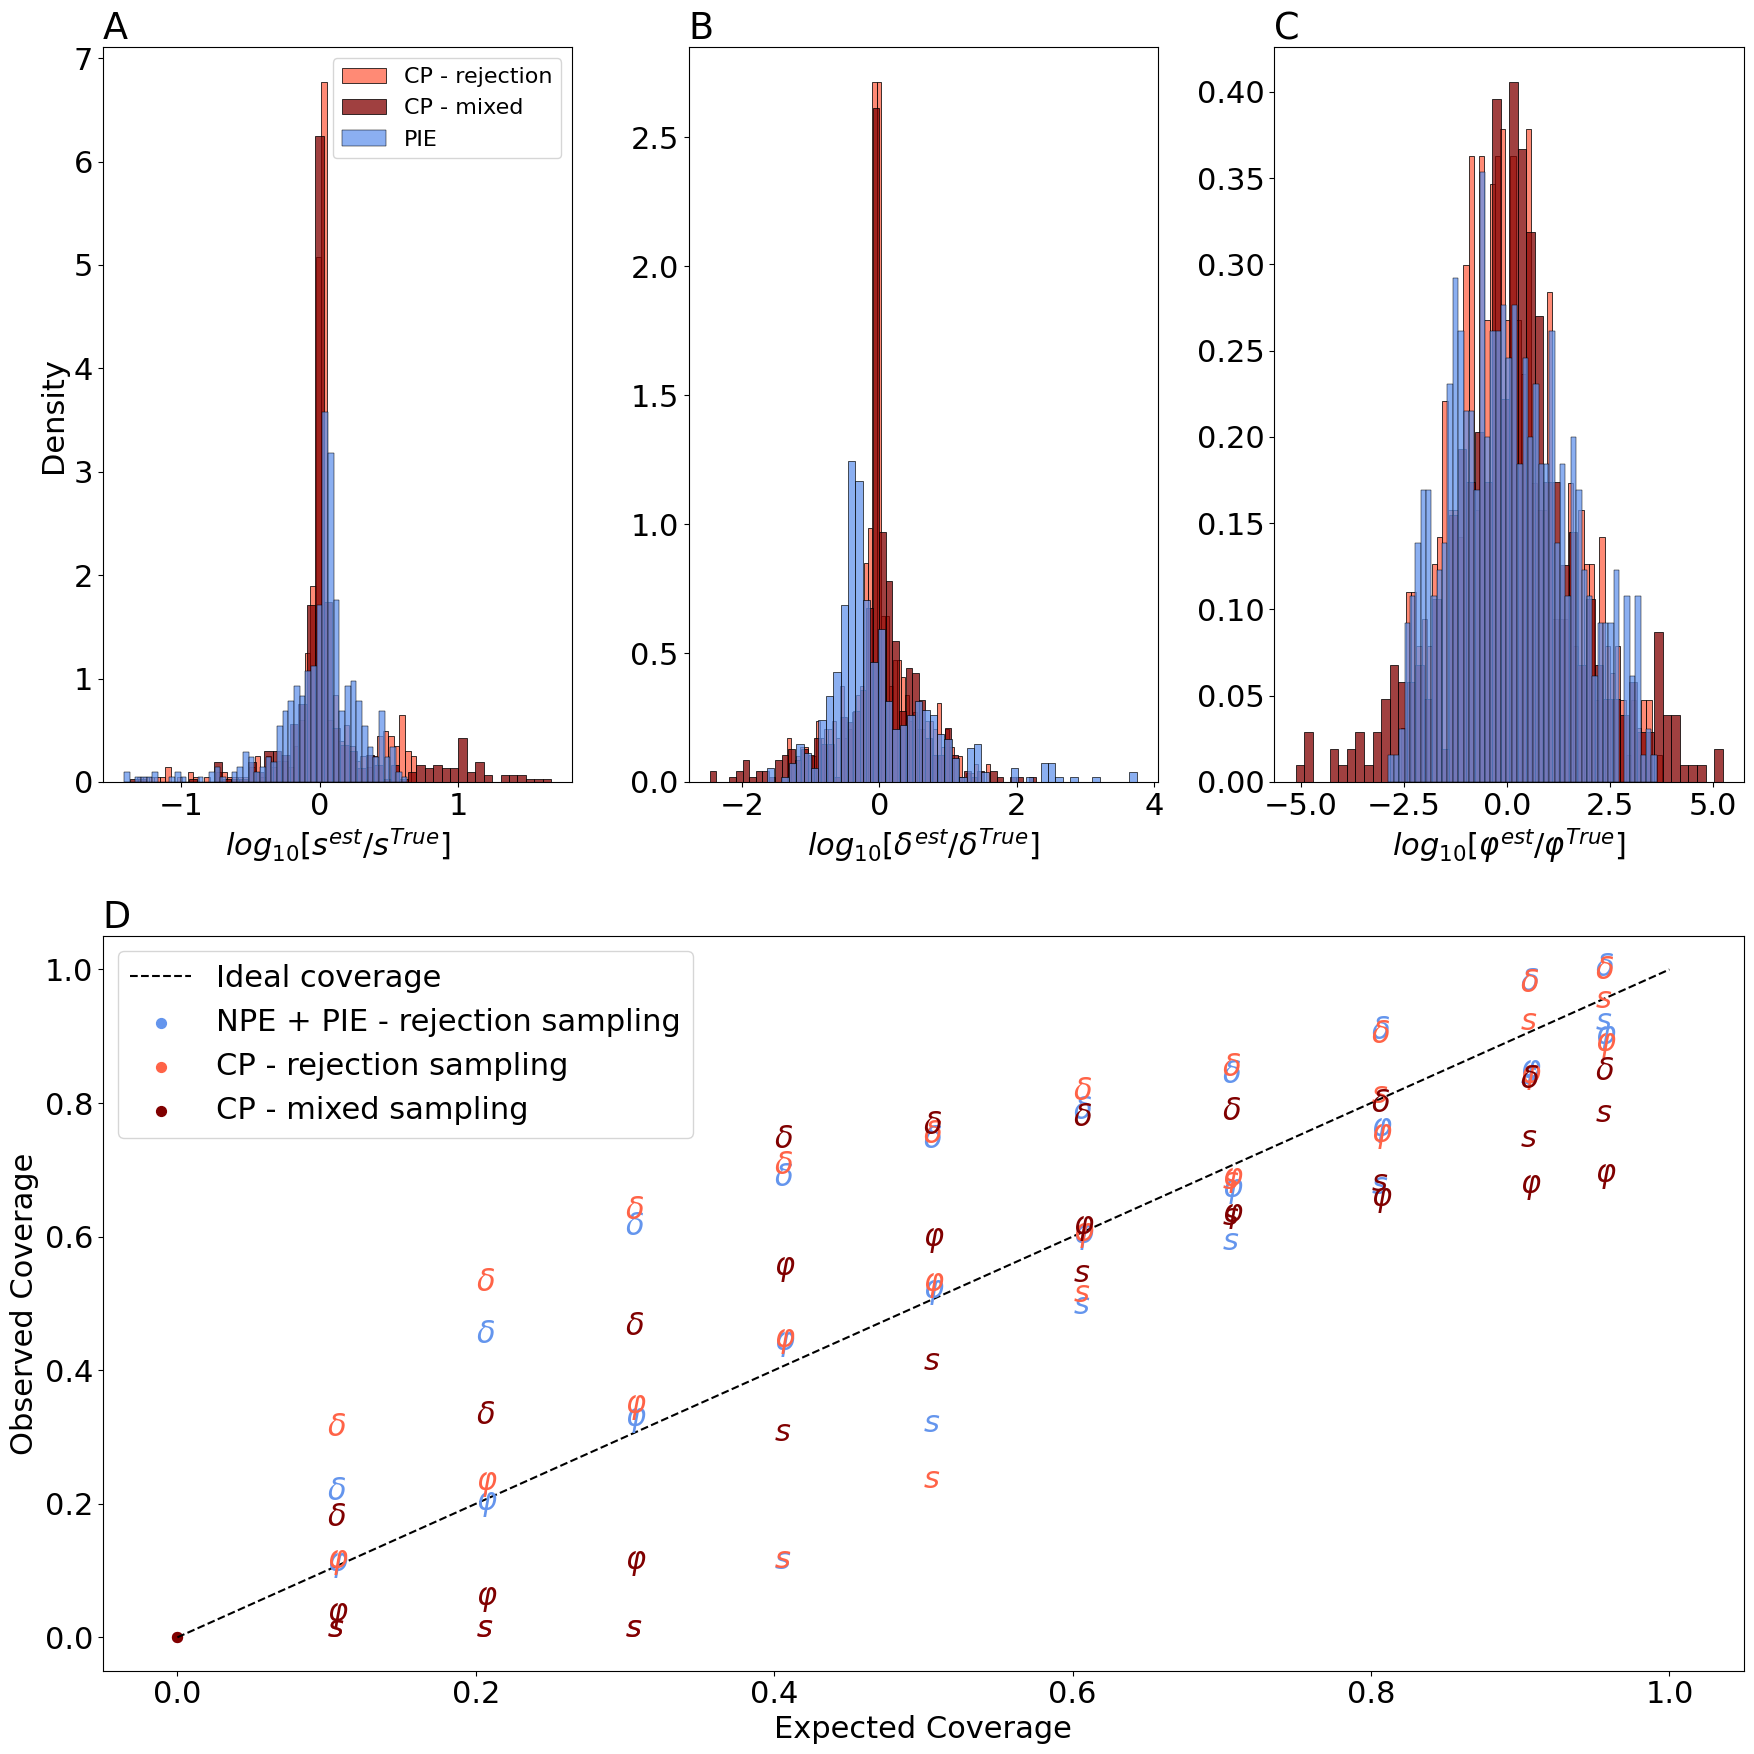

In [13]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE - rejection sampling',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='CP - rejection sampling',color='tomato')
plot_covs_old(ax=ax['D'], covs=covs_cp_m,label='CP - mixed sampling',color='maroon')
ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['D'].legend()



n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='CP - rejection')

cp_m_acc = 'tests/accus_WF_m.csv'
plot_accuracy(cp_m_acc, axx, color='maroon', hatch='', label='CP - mixed')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='PIE')

ax['A'].legend(loc='upper right', fontsize=16)
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



Text(0, 0.5, '')

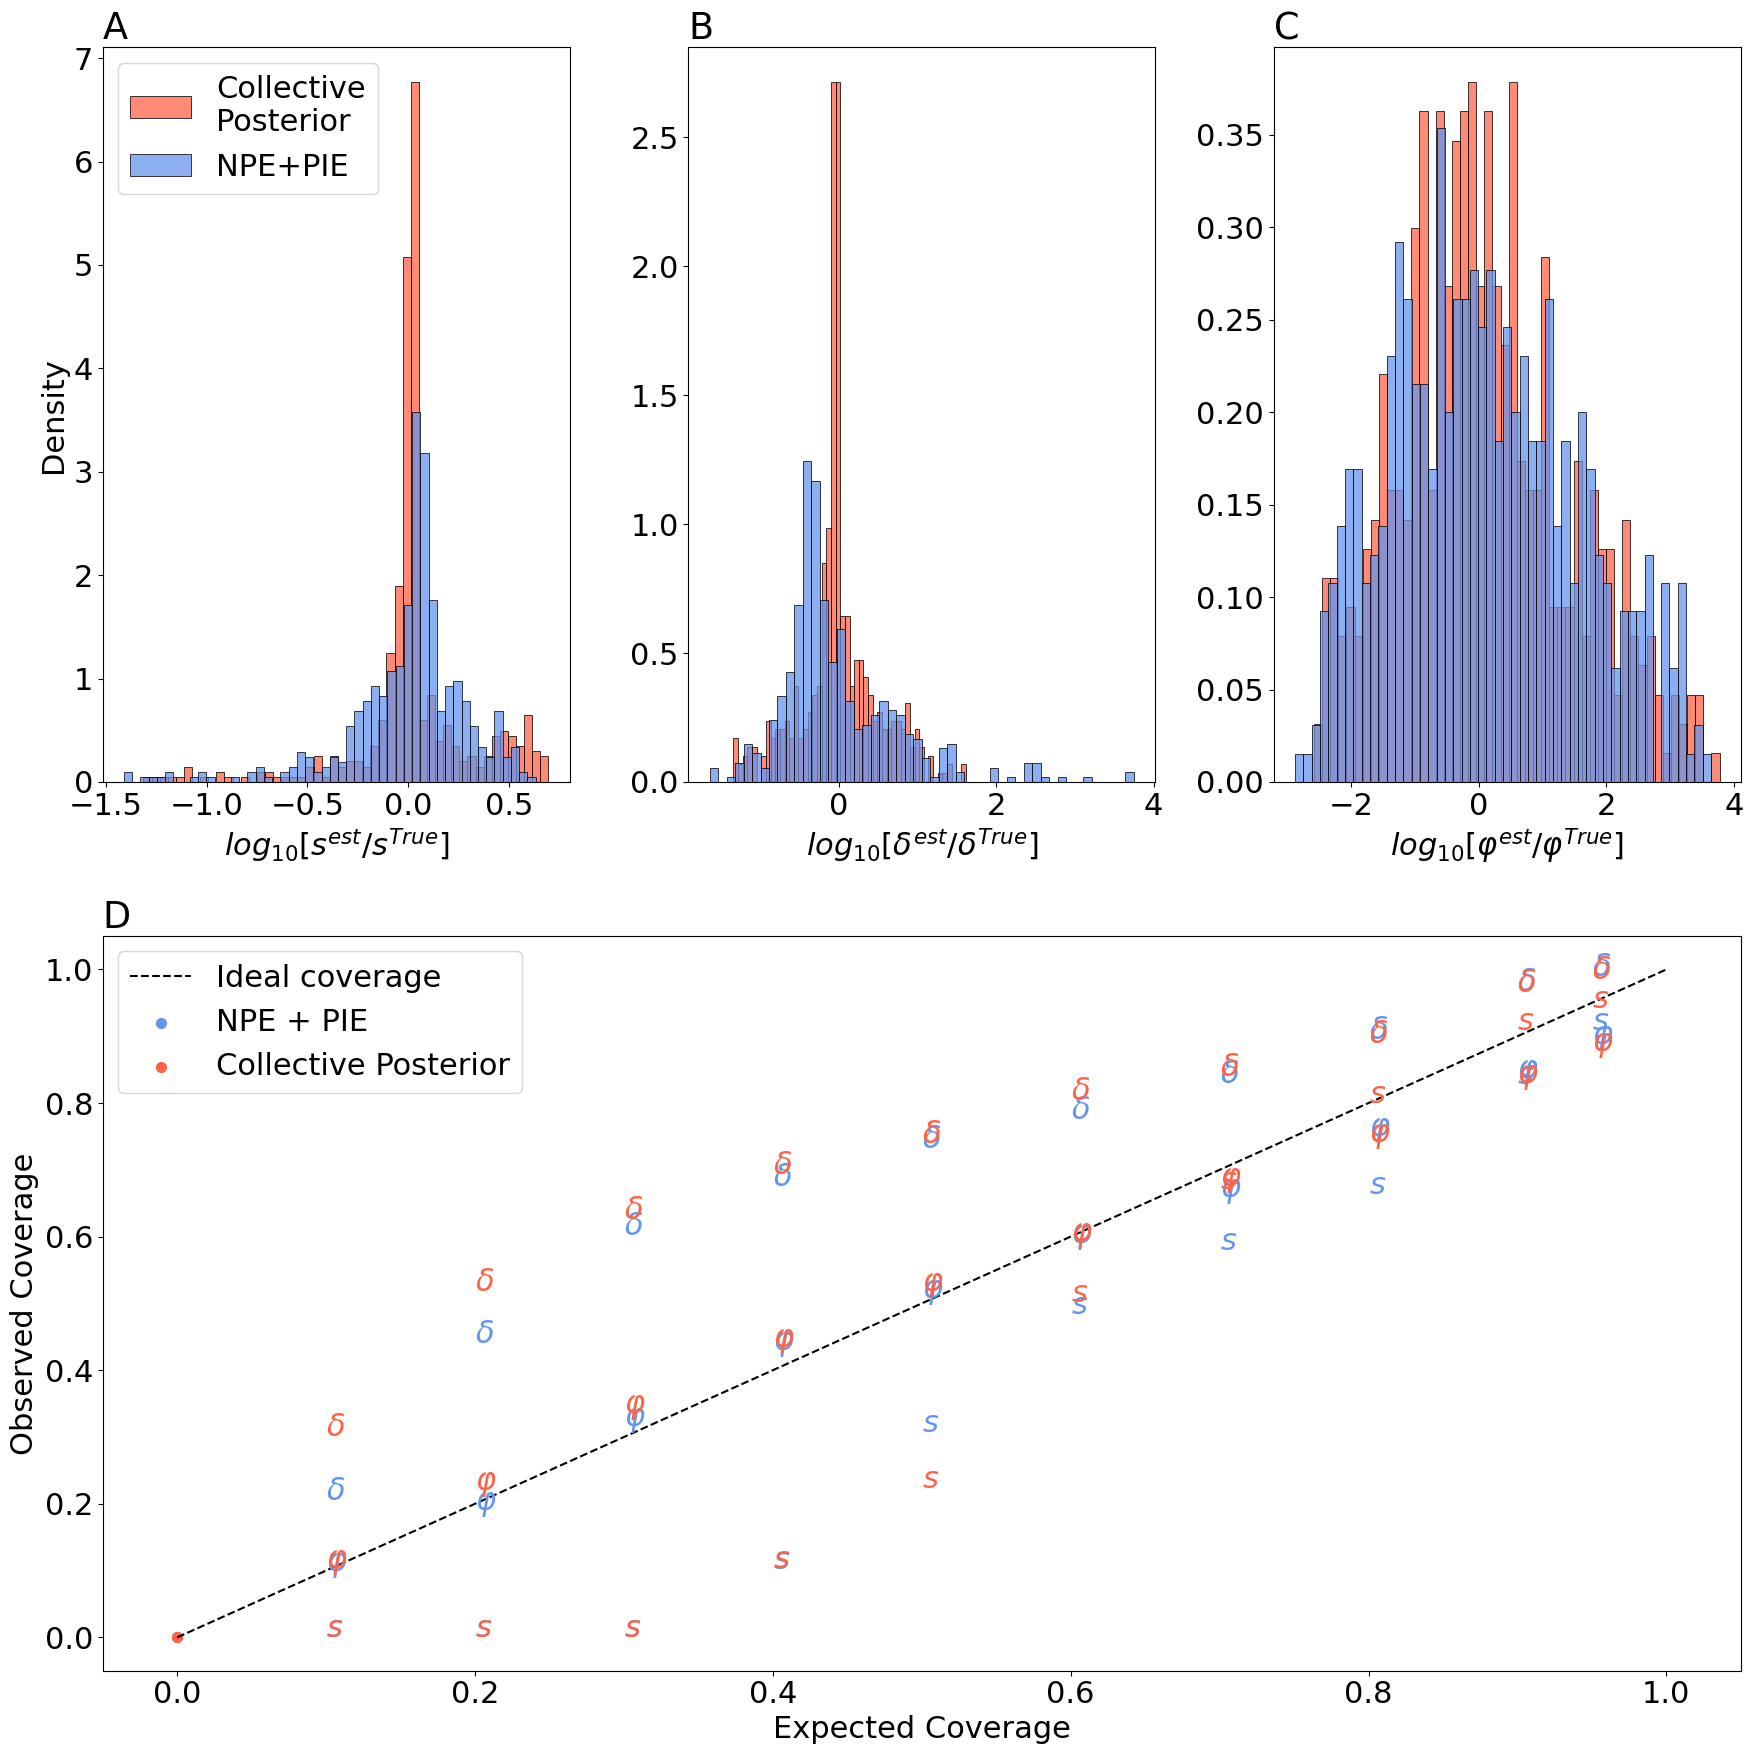

In [15]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='Collective Posterior',color='tomato')


n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['A'].legend()
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



In [29]:
thetas = pd.read_csv('tests/test_thetas.csv', index_col=0)
thetas = torch.from_numpy(np.array(thetas))

cpa = pd.read_csv(cp_acc, index_col=0)
cpa = torch.from_numpy(np.array(cpa))
print(cpa.median(0))
iida = pd.read_csv(iid_acc, index_col=0)
iida = torch.from_numpy(np.array(iida))
print(iida.median(0))

torch.return_types.median(
values=tensor([ 0.0144, -0.0354, -0.0550], dtype=torch.float64),
indices=tensor([119,  11,  95]))
torch.return_types.median(
values=tensor([ 0.0492, -0.2277, -0.0086], dtype=torch.float64),
indices=tensor([ 27,  49, 332]))
